Datasets nettoyés chargés :
  Bruteforce         → 5097 lignes, 45 colonnes
  DDoS               → 14292 lignes, 45 colonnes
  DoS                → 14121 lignes, 45 colonnes
  Evil               → 10 lignes, 45 colonnes
  Fakelanding        → 69 lignes, 45 colonnes
  MITM               → 208 lignes, 45 colonnes
  Normal             → 36806 lignes, 45 colonnes
  Reconnassiance     → 1152 lignes, 45 colonnes
  Reply              → 202 lignes, 45 colonnes
  Scanning           → 1152 lignes, 45 colonnes
  UAVIDS-2025        → 113952 lignes, 20 colonnes

Features : 19 colonnes
Labels   : <ArrowStringArray>
[    'Sybil Attack', 'Blackhole Attack',  'Wormhole Attack',
  'Flooding Attack',   'Normal Traffic']
Length: 5, dtype: str


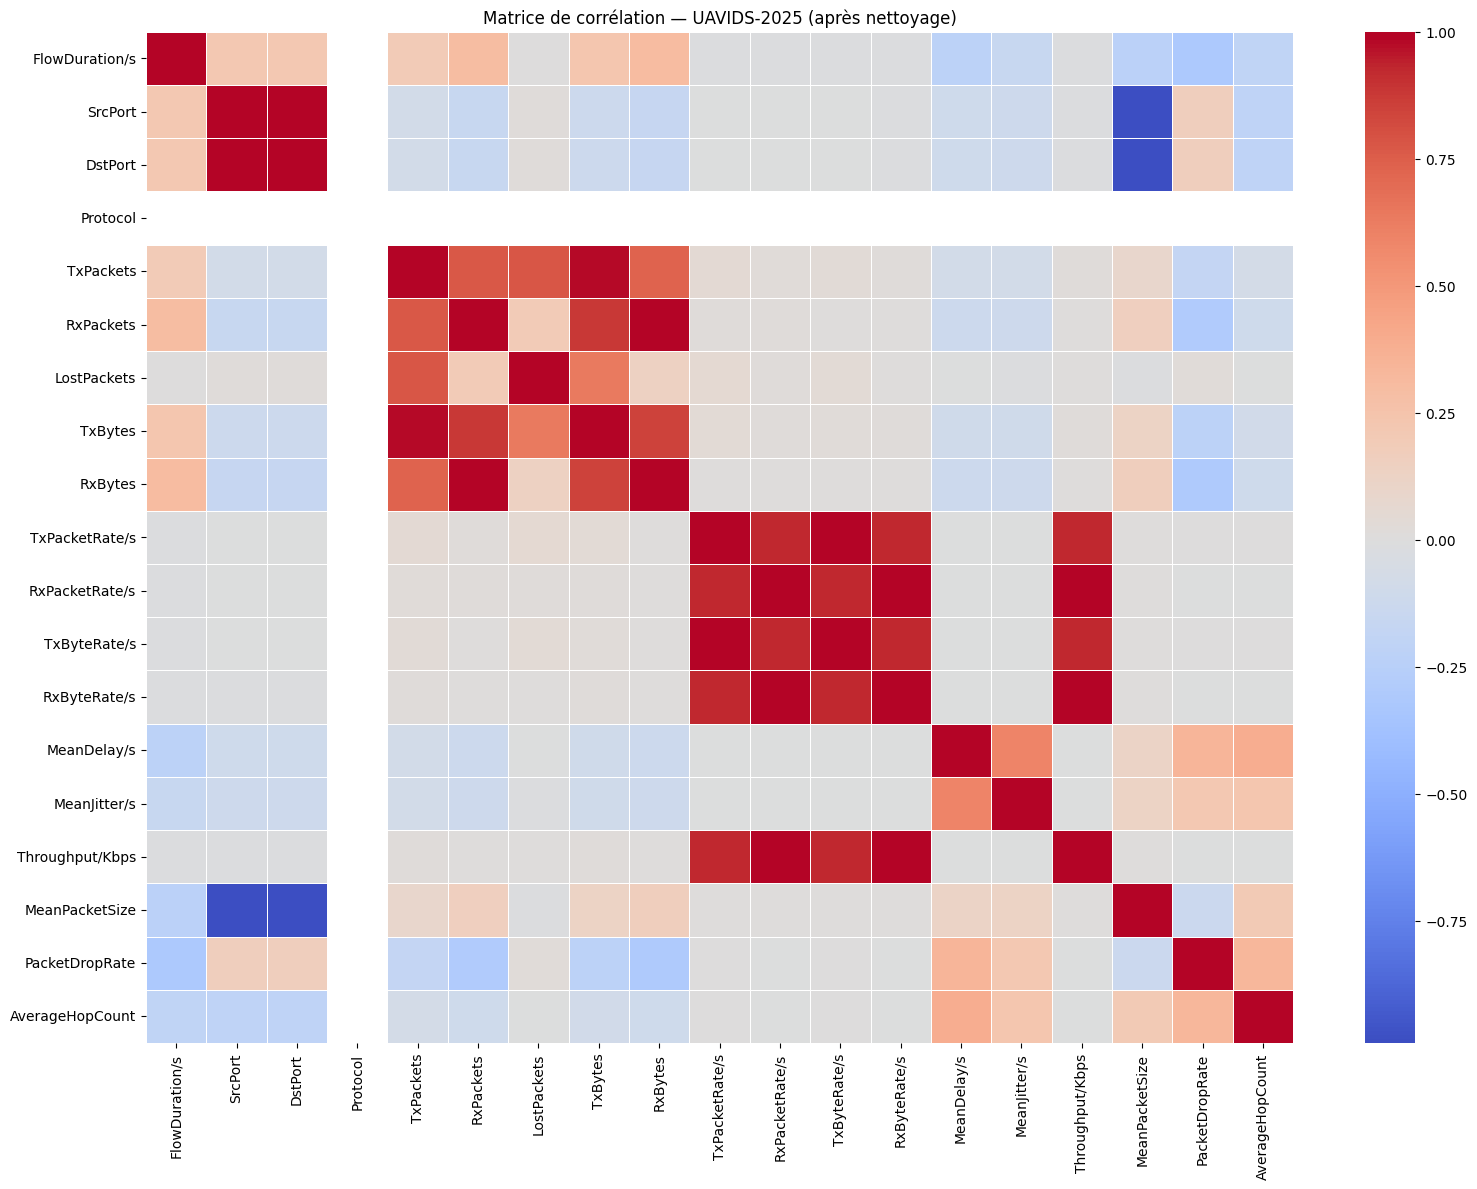

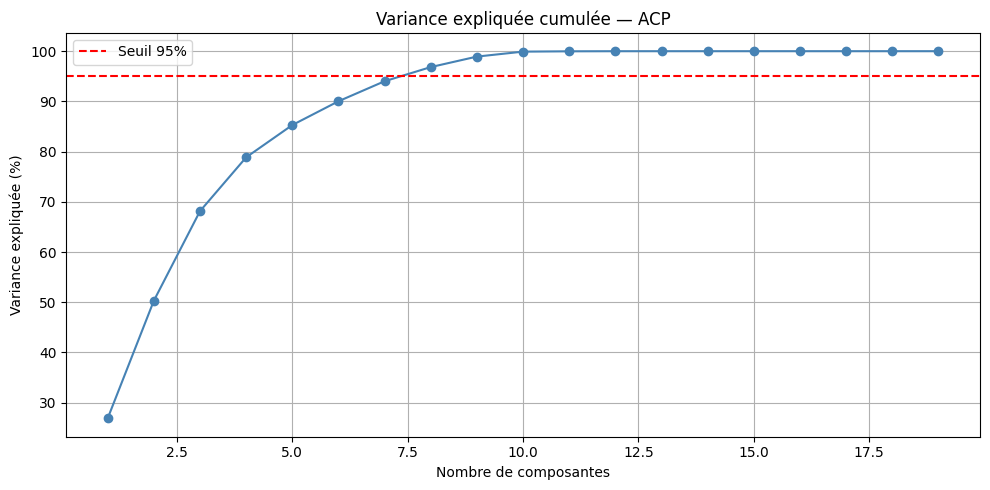


→ 8 composantes suffisent pour expliquer 95% de la variance
→ Shape après ACP : (113952, 8)


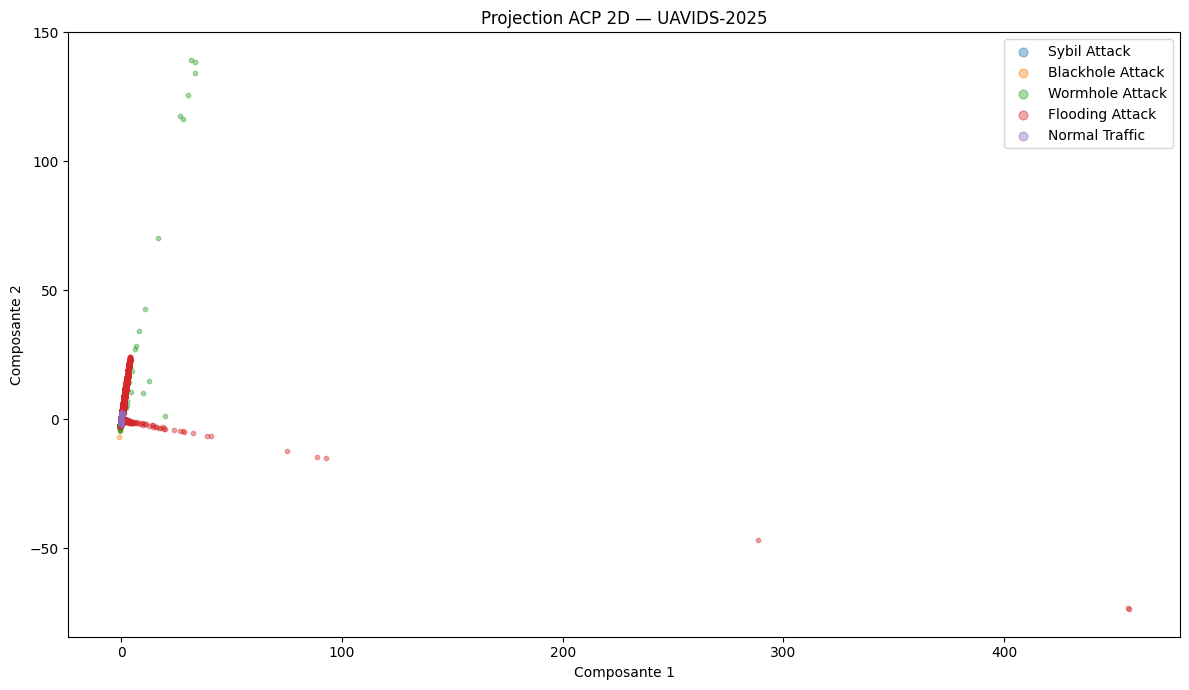


Données prétraitées sauvegardées dans DATASET/Final/
Variance ACP exportée dans Rapport/tables/ACP_variance.csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Rechargement des données nettoyées
nettoyees_path = r"C:\Drone_Attack_Similarity_Project\DATASET\Nettoyées"
figures_path   = r"C:\Drone_Attack_Similarity_Project\Rapport\figures"
tables_path    = r"C:\Drone_Attack_Similarity_Project\Rapport\tables"
os.makedirs(figures_path, exist_ok=True)
os.makedirs(tables_path, exist_ok=True)

datasets_clean = {}
for filename in os.listdir(nettoyees_path):
    if filename.endswith("_clean.csv"):
        name = filename.replace("_clean.csv", "").replace("_", "-")
        datasets_clean[name] = pd.read_csv(f"{nettoyees_path}\\{filename}")

print("Datasets nettoyés chargés :")
for name, df in datasets_clean.items():
    print(f"  {name:<18} → {df.shape[0]} lignes, {df.shape[1]} colonnes")

######### Prétraitement des données ########

df = datasets_clean["UAVIDS-2025"]

# 1. Séparation features / label
X = df.drop(columns=["label"])
y = df["label"]

print(f"\nFeatures : {X.shape[1]} colonnes")
print(f"Labels   : {y.unique()}")

# 2. Matrice de corrélation (après nettoyage)
plt.figure(figsize=(16, 12))
sns.heatmap(
    X.corr(),
    annot=False,
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)
plt.title("Matrice de corrélation — UAVIDS-2025 (après nettoyage)")
plt.tight_layout()
plt.savefig(f"{figures_path}\\Matrice_de_correlation.png", dpi=150)
plt.show()

# 3. ACP — Réduction de dimensionnalité
# Standardisation avant ACP
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ACP complète pour voir la variance expliquée
pca_full = PCA()
pca_full.fit(X_scaled)

variance_cumulee = np.cumsum(pca_full.explained_variance_ratio_) * 100

# Graphique variance expliquée
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(variance_cumulee) + 1), variance_cumulee,
         marker="o", color="steelblue")
plt.axhline(y=95, color="red", linestyle="--", label="Seuil 95%")
plt.title("Variance expliquée cumulée — ACP")
plt.xlabel("Nombre de composantes")
plt.ylabel("Variance expliquée (%)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(f"{figures_path}\\ACP_variance_expliquee.png", dpi=150)
plt.show()

# Nombre de composantes pour 95% de variance
n_components = np.argmax(variance_cumulee >= 95) + 1
print(f"\n→ {n_components} composantes suffisent pour expliquer 95% de la variance")

# ACP(Analyse des composantes principales) finale avec le bon nombre de composantes
pca = PCA(n_components=n_components)
X_pca = pca.fit_transform(X_scaled)

print(f"→ Shape après ACP : {X_pca.shape}")

# 4. Visualisation ACP 2D
pca_2d = PCA(n_components=2)
X_2d = pca_2d.fit_transform(X_scaled)

plt.figure(figsize=(12, 7))
for label in y.unique():
    mask = y == label
    plt.scatter(X_2d[mask, 0], X_2d[mask, 1], label=label, alpha=0.4, s=10)

plt.title("Projection ACP 2D — UAVIDS-2025")
plt.xlabel("Composante 1")
plt.ylabel("Composante 2")
plt.legend(loc="best", markerscale=2)
plt.tight_layout()
plt.savefig(f"{figures_path}\\ACP_2D.png", dpi=150)
plt.show()

# 5. Sauvegarde des données prétraitées
final_path = r"C:\Drone_Attack_Similarity_Project\DATASET\Final"
os.makedirs(final_path, exist_ok=True)

# Sauvegarde X_pca + labels
df_pca = pd.DataFrame(
    X_pca,
    columns=[f"PC{i+1}" for i in range(n_components)]
)
df_pca["label"] = y.values
df_pca.to_csv(f"{final_path}\\UAVIDS_2025_pca.csv", index=False)

# Sauvegarde variance expliquée dans tables
variance_df = pd.DataFrame({
    "Composante"        : range(1, len(pca_full.explained_variance_ratio_) + 1),
    "Variance_expliquee": pca_full.explained_variance_ratio_ * 100,
    "Variance_cumulee"  : variance_cumulee,
})
variance_df.to_csv(f"{tables_path}\\ACP_variance.csv", index=False)

print(f"\nDonnées prétraitées sauvegardées dans DATASET/Final/")
print(f"Variance ACP exportée dans Rapport/tables/ACP_variance.csv")